In [82]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3
import numpy as np

import database (sql)


In [83]:
conn=sqlite3.connect('customer_churn.db')
sql_query="""
select name from sqlite_master where type='table'
"""

In [84]:
tables=pd.read_sql(""" select name from sqlite_master where type='table' """,conn)
tables

,name
0,db_customer
1,db_subscription
2,db_support


create dataframe

In [85]:
for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f'df_{table_name}']=df
    print(f'created dataframe: df_{table_name}')
conn.close()

created dataframe: df_db_customer
created dataframe: df_db_subscription
created dataframe: df_db_support


removing the unnessary columns


In [86]:
df_db_customer.drop(columns=['interests','pincode'],inplace=True)


changin data type of dob column

In [87]:
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

data standardization -gender 

In [88]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

updating missing values

In [89]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [90]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

now miving on next table

In [91]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


now changin the data type of dates columns 

In [92]:
date_col=['subscription_start_date','cancellation_date','renewal_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


now the last table 

In [93]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [94]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)


changing data type of date 

In [95]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [96]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


.................................... Feature engineering and data analysis ...........................................

adding a flag to churn users

creating a new col using existing col 

In [97]:
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [98]:
df_db_customer.shape

(21, 6)

removing duplicates from df_db_support 

In [99]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [100]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

now merging the data

In [101]:
df=(df_db_subscription
    .merge(df_db_customer,on="customerid",how='left')
    .merge(df_db_support,on='customerid',how='left'))


In [102]:
df.shape

(21, 21)

In [103]:
df=pd.read_csv('exported-churn-data.csv')
df.shape

(21, 21)

churn rate

In [104]:
churn_rate=df['churn_flag'].mean()*100
print("churn rate = ",round(churn_rate,2),"%")

churn rate =  28.57 %


retension rate


In [105]:
retension_rate =(100-churn_rate)
print("retension rate = ",round(retension_rate,2),"%")


retension rate =  71.43 %


In [106]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN


 3 churn by plan type 

In [107]:
churnbyplan=df.groupby('plan_type')['churn_flag'].mean().reset_index()

State wise churn rate 

In [108]:
churn_by_state=df.groupby(['state','plan_type'])['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(churn_by_state,)

            state plan_type  churn_rate_pct
0           Delhi     Basic            0.00
1           Delhi  Standard           33.33
2       Karnataka   Premium          100.00
3       Karnataka  Standard          100.00
4       Kathmandu     Basic            0.00
5       Kathmandu  Standard            0.00
6     Maharashtra   Premium            0.00
7     Maharashtra  Standard            0.00
8       Meghalaya     Basic          100.00
9       Meghalaya   Premium            0.00
10       Nagaland   Premium            0.00
11      Rajasthan   Premium            0.00
12      Rajasthan  Standard            0.00
13      Telangana     Basic          100.00
14      Telangana  Standard            0.00
15  Uttar Pradesh   Premium            0.00


In [109]:
premium_users_in_karnataka=df[(df['state']=='Karnataka') & (df['plan_type']=="Premium")][['customerid','name']]
print(premium_users_in_karnataka)

   customerid    name
1  0003-MKNFE  raghav


totle revenue

In [110]:
totle_revenue=df['monthly_charges'].sum()
totle_revenue.round(2)

np.float64(395.79)

Average revenue per

In [111]:
average_revenue=df['monthly_charges'].mean()
average_revenue.round(2)

np.float64(18.85)

In [112]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

average customer tenure

In [113]:
df['subscription_start_date'] = pd.to_datetime(
    df['subscription_start_date'],
    errors='coerce'
)

df['cancellation_date'] = pd.to_datetime(
    df['cancellation_date'],
    errors='coerce'
)

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

In [114]:
average_tenure=df['tenure_days'].mean().round()
average_tenure


np.float64(1501.0)

revenue lost from churn user 

In [115]:
revenue_loss=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print('revenue loss in k',revenue_loss)

revenue loss in k 73.94


Esclation rate 

In [116]:
exclation_rate=(df['escalations']=='Y').mean()*100
exclation_rate.round(2),"%"

(np.float64(19.05), '%')

Average complaint per user

In [117]:
avg_complaints_per_user=df['complaint_count'].fillna(0).sum() /df['customerid'].nunique()
(avg_complaints_per_user*100)

np.float64(42.857142857142854)

Correlation  Escaltion vs churn 

In [118]:
df['escalations'] = np.where(df['escalations'] == "Y", 1, 0)

corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

round(correlation, 2)

np.float64(0.77)

Churn risk - create a coloum using existing col

In [119]:
conditions =[
    
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
    
]

choices=['low','medium','high']
df['churn_risk']= np.select(conditions,choices,default='unknown')

In [120]:
df[['churn_score','churn_risk']].head()
df[df['churn_risk']=='high'][['churn_score','churn_risk']]

,churn_score,churn_risk
1,91,high
4,88,high
6,79,high
11,83,high
13,76,high
18,99,high


.....................Data visualization .......................

In [121]:
df_visual=df.copy()
df_visual.shape

(21, 23)

Monthly churn rate 

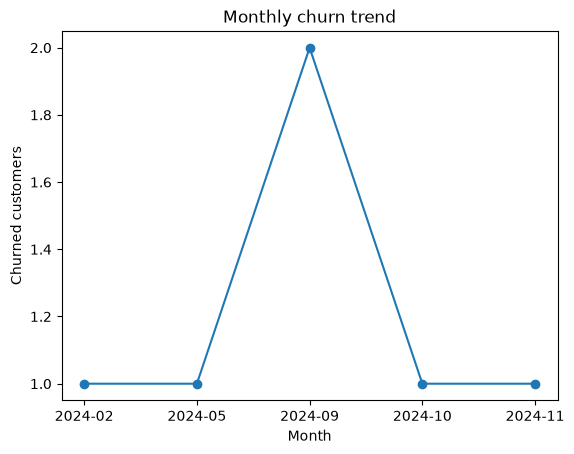

In [122]:
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.plot(churn_trend.index.astype(str),churn_trend.values,marker='o')
plt.title("Monthly churn trend")
plt.xlabel('Month')
plt.ylabel("Churned customers")
plt.savefig("Montly Churn trend")


churn by plan type 

In [123]:
import plotly.express as px

churn_plan = (
    df_visual.groupby('plan_type')['churn_flag']
    .mean()
    .reset_index()
)

churn_plan['churn_rate'] = churn_plan['churn_flag'] * 100

fig = px.bar(
    churn_plan,
    x='plan_type',
    y='churn_rate',
    text='churn_rate',
    title='Churn Rate by Plan Type',
    labels={
        'plan_type': 'Plan Type',
        'churn_rate': 'Churn Rate (%)'
    },
    hover_data={'churn_rate': ':.2f'}
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    yaxis_range=[0, 100],
    hovermode='x unified'
)

fig.show()
fig.write_image("churn_rate_by_plan.png")

churn b states 

In [124]:
import plotly.express as px

churn_states = (
    df_visual.groupby('state')['churn_flag']
    .mean()
    .reset_index()
)

churn_states['churn_rate'] = churn_states['churn_flag'] * 100

fig = px.bar(
    churn_states,
    x='churn_rate',
    y='state',
    orientation='h',
    text='churn_rate',
    title='Churn Rate by State',
    labels={
        'churn_rate': 'Churn Rate (%)',
        'state': 'State'
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_range=[0, 100]
)

fig.show()
fig.write_image("Churn rate by state.png")

heatmap(correlation )

In [125]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [126]:
df_encoded=df_visual[[
        'plan_type', 'contract_type',
        'churn_score',
       'churn_flag', 
       'escalations','churn_risk']]
order_mapping ={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
    
}
for col,order in order_mapping.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes
df_encoded.head()


C:\Users\dell\AppData\Local\Temp\ipykernel_9300\588959536.py:13: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes


,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


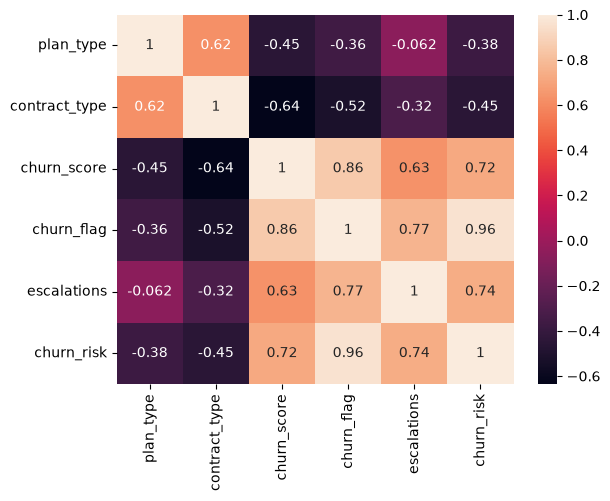

In [127]:
sns.heatmap(df_encoded.corr(),annot=True)
plt.savefig("correlation")

pair plot

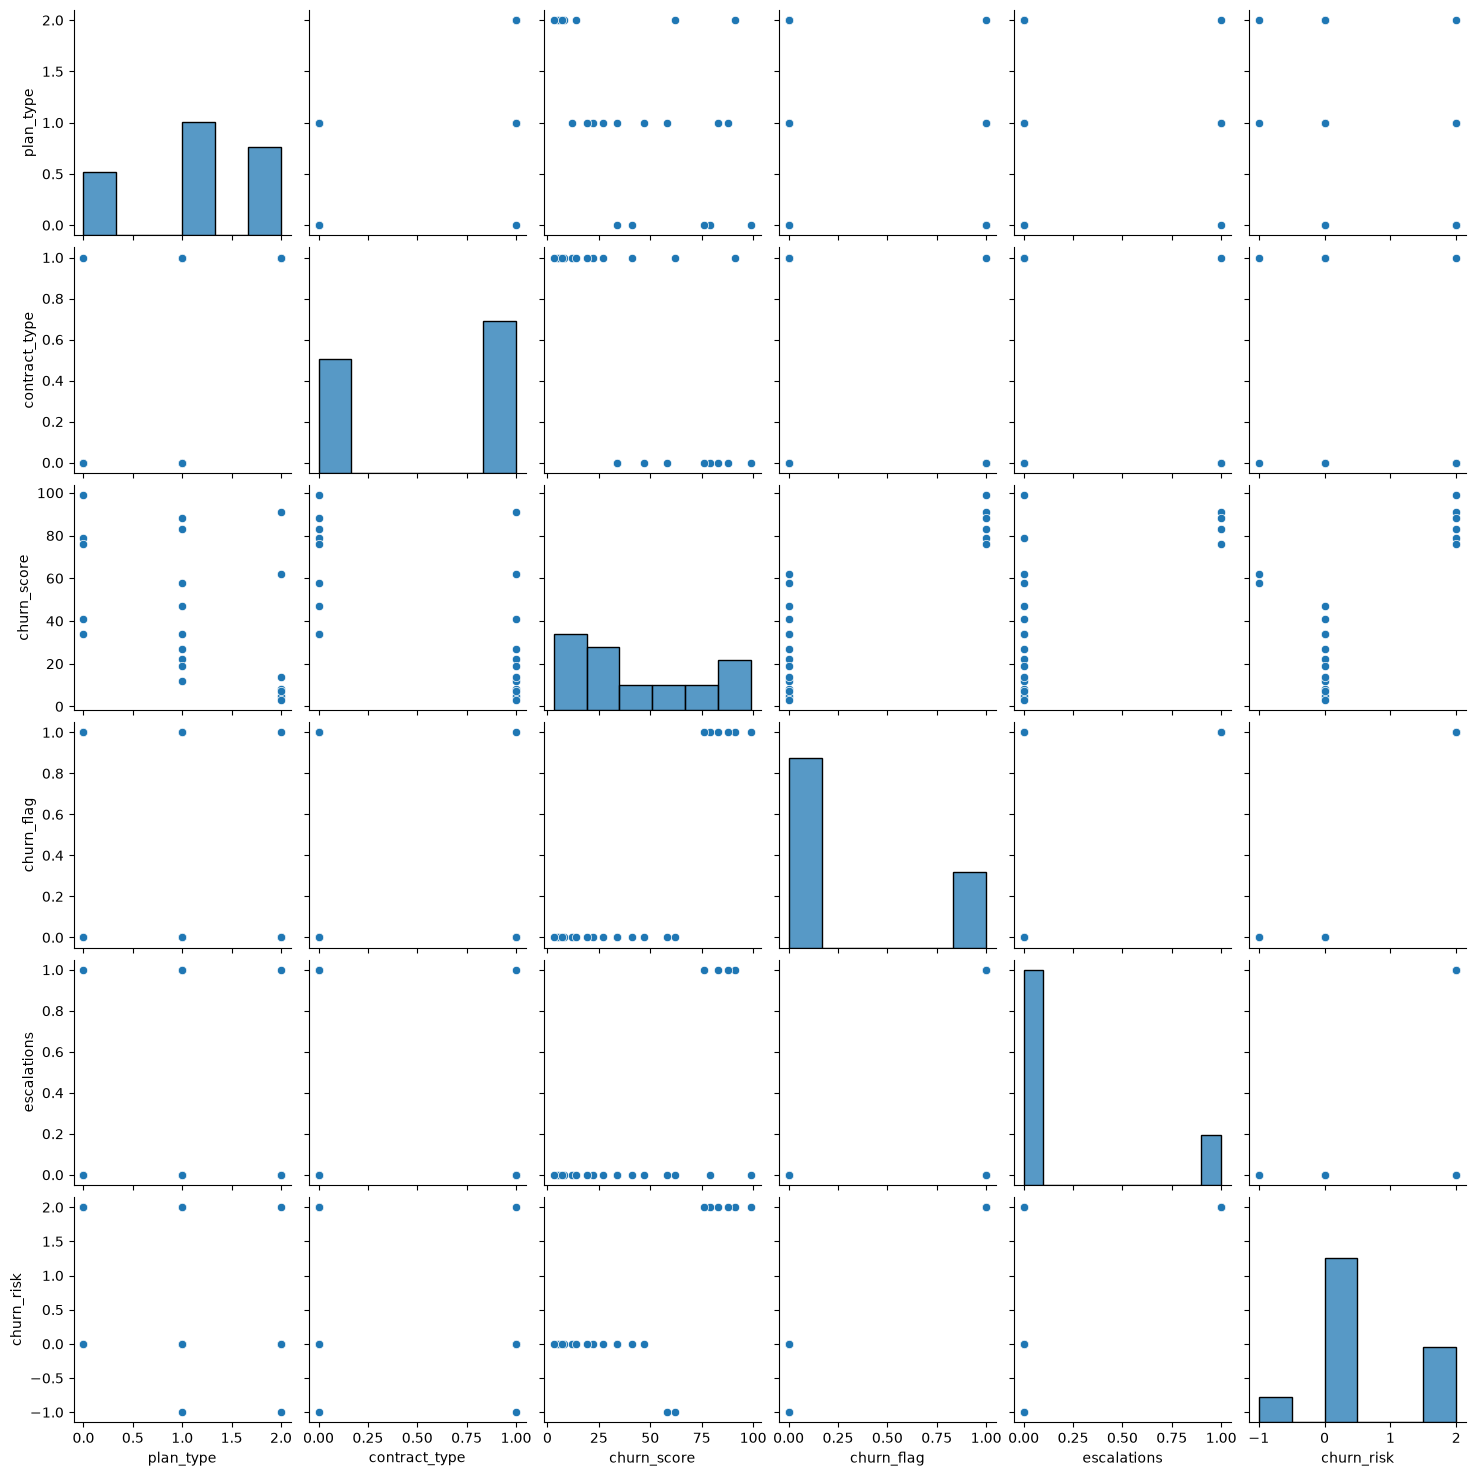

In [128]:
sns.pairplot(df_encoded)
plt.savefig("pairplot charts combination")

categorical/facegrid chart

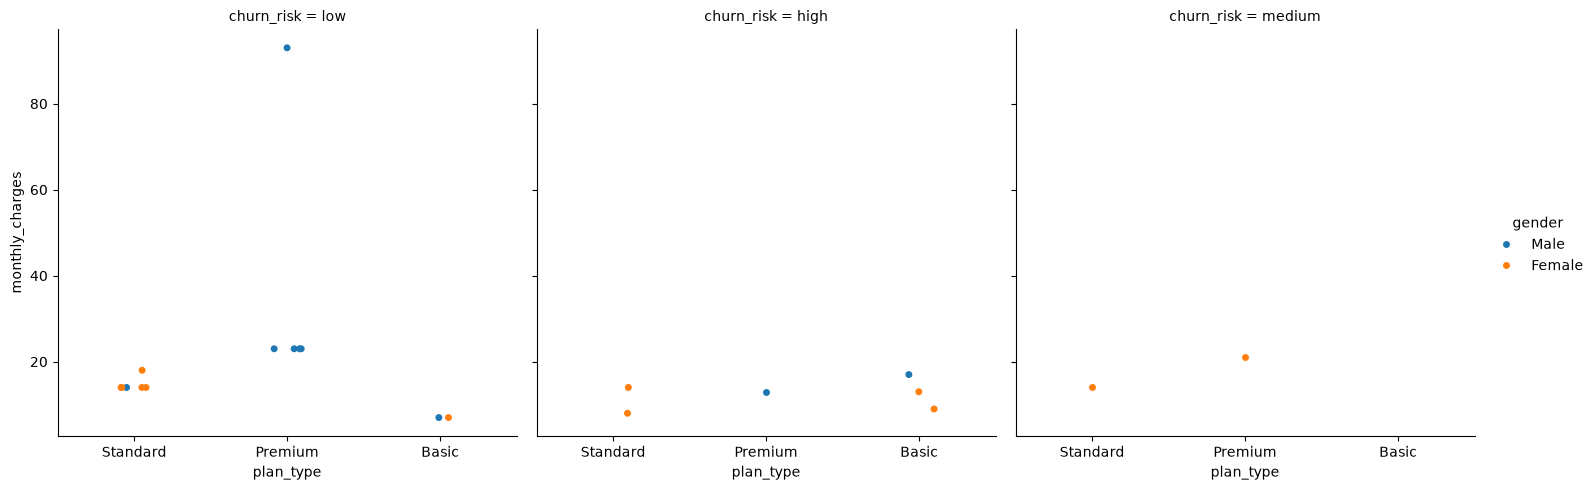

In [129]:
sns.catplot(data=df_visual,x="plan_type",y="monthly_charges",hue="gender",col="churn_risk")
plt.savefig('categorical visualization')

pivot table 

In [130]:
pd.pivot_table(
    df_visual,
    values="churn_flag",
    index='plan_type',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [131]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [132]:
pd.pivot_table(
    df_visual,
    values=["churn_flag",'customerid','monthly_charges'],
    index='plan_type',
    aggfunc={
        "churn_flag":'mean',
        'customerid':"nunique",
        'monthly_charges':"sum"
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [133]:
conn=sqlite3.connect("test_database.sqlite")
#table details 
#conn.execute("create table users(first_name text,country text,budget integer)")
#commit and save 
conn.commit()

In [134]:
#insert data 
cursor=conn.cursor()
cursor.execute(
    """ INSERT INTO users (first_name, country, budget) VALUES
    ('Madhav', 'India', 5000),
    ('Rahul', 'India', 6500),
    ('Aman', 'India', 7200),
    ('Priya', 'India', 5800),
    ('Neha', 'India', 8000),
    ('Arjun', 'India', 9000),
    ('Rohan', 'India', 4500),
    ('Anjali', 'India', 7000),
    ('Vikas', 'India', 6200),
    ('Sneha', 'India', 7500),
    ('David', 'USA', 12000),
    ('John', 'USA', 15000),
    ('Emma', 'UK', 11000),
    ('Oliver', 'UK', 13000),
    ('Sophia', 'Canada', 10000),
    ('Liam', 'Canada', 11500),
    ('Daniel', 'Australia', 14000),
    ('Ava', 'Australia', 12500),
    ('Noah', 'Germany', 10500),
    ('Mia', 'France', 9500);
    """
)
conn.commit()

In [137]:
conn=sqlite3.connect('test_database.sqlite')
query="""select * from users """
df_results =pd.read_sql(query,conn)
df_results

,first_name,country,budget
0,Madhav,India,5000
1,Rahul,India,6500
2,Aman,India,7200
3,Priya,India,5800
4,Neha,India,8000
5,Arjun,India,9000
6,Rohan,India,4500
7,Anjali,India,7000
8,Vikas,India,6200
9,Sneha,India,7500
